# Exploratory Data Analysis (EDA)
## Rx Drug Marketing Mix Modeling (MMIX)

### Business Context

Pharmaceutical firms compete within therapeutic classes, where multiple brands seek to influence prescriptions through two primary channels:

- **Detailing**: physician-targeted promotion
- **DTCA**: direct-to-consumer advertising

The commercial mechanism is:

> Marketing investment → influences physicians and patients → drives prescriptions → generates sales

### Business Objective

The goal of this analysis is to understand how marketing investments translate into sales outcomes across brands and therapeutic classes, and to identify patterns that should guide model design and budget decisions.

### Core Business Questions

1. Which brands dominate portfolio revenue, and how concentrated is the portfolio?
2. How has portfolio performance evolved over time?
3. How are detailing and DTCA budgets allocated across brands and classes?
4. Which channel appears more efficient before formal modeling?
5. Is there evidence of diminishing returns to marketing spend?
6. Do classes and brands differ in baseline sales and marketing sensitivity?
7. Are there structurally different marketing regimes, especially around zero DTCA?
8. What does the panel structure imply for modeling and validation?

### Scope of Analysis
This review encompasses an 11-year historical dataset, capturing the following parameters:
* Observation Period: 2013–2024
* Therapeutic Classes: PPI (Proton Pump Inhibitors), SSRI (Antidepressants), Statin (Cholesterol)
* Portfolio Size: 22 distinct brands
* Key Metrics Evaluated:
    * Top-line Sales in Billions of Dollars
    * Physician Detailing Spend in Millions of Dollars
    * Direct-to-Consumer Advertising (DTCA) Spend ($ Millions)

In [43]:
print("\n[EDA] Importing libraries...")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("[EDA] Libraries loaded successfully.")


[EDA] Importing libraries...
[EDA] Libraries loaded successfully.


In [44]:
print("\n[EDA] Loading dataset and standardizing column names...")

df = pd.read_excel("data/MMM_Drug_Data.xlsx")

df = df.rename(columns={
    "Class": "class",
    "Agent": "agent",
    "Year": "year",
    "Detailing": "detailing",
    "Direct-to-Consumer Advertising (DTCA)": "direct_to_consumer_ad",
    "Actual Sales": "actual_sales"
})

print("[EDA] Dataset loaded successfully.")
display(df.head())


[EDA] Loading dataset and standardizing column names...
[EDA] Dataset loaded successfully.


,class,agent,year,detailing,direct_to_consumer_ad,actual_sales
0,PPI,Prevacid,2013,43.8805,0.0000,2.9083
1,PPI,Prilosec,2013,41.6480,0.0000,14.7235
2,SSRI,Luvox,2013,22.3667,0.0000,0.9120
3,SSRI,Paxil,2013,57.4608,0.0000,11.2677
4,SSRI,Prozac,2013,84.5333,0.0000,20.2600


In [45]:
print("\n[EDA] Running initial data checks...")

print("Shape:", df.shape)

print("\nColumn types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().to_frame("missing_count"))

print("\nYears covered:", df["year"].min(), "to", df["year"].max())
print("Number of classes:", df["class"].nunique())
print("Number of agents:", df["agent"].nunique())

print("\n[Business Insight]")
print("The dataset covers 12 years, 22 brands, and 3 therapeutic classes with no missing values.")
print("This supports both cross-sectional and panel-style analysis.")


[EDA] Running initial data checks...
Shape: (207, 6)

Column types:


,dtype
class,str
agent,str
year,int64
detailing,float64
direct_to_consumer_ad,float64
actual_sales,float64



Missing values:


,missing_count
class,0
agent,0
year,0
detailing,0
direct_to_consumer_ad,0
actual_sales,0



Years covered: 2013 to 2024
Number of classes: 3
Number of agents: 22

[Business Insight]
The dataset covers 12 years, 22 brands, and 3 therapeutic classes with no missing values.
This supports both cross-sectional and panel-style analysis.


In [46]:
print("\n[EDA] Checking panel structure (agent × year)...")

panel = pd.crosstab(df["agent"], df["year"])

n_agents = df["agent"].nunique()
n_years = df["year"].nunique()
expected_rows = n_agents * n_years
actual_rows = len(df)

print(f"Expected rows in a balanced panel: {expected_rows}")
print(f"Actual rows observed: {actual_rows}")
print(f"Missing agent-year combinations: {expected_rows - actual_rows}")

display(panel)

test_agents = set(df[df["year"] >= 2023]["agent"].unique())
train_agents = set(df[df["year"] <= 2020]["agent"].unique())

print("\n[EDA] Train/test overlap check for future time-based modeling...")
print(f"Agents in test (2023-2024) but not in train (<=2020): {test_agents - train_agents or 'None'}")
print(f"Agents in train (<=2020) but not in test (2023-2024): {train_agents - test_agents or 'None'}")

print("\n[Business Insight]")
print("The portfolio is an unbalanced panel, which is realistic for markets where brands launch, mature, or exit over time.")
print("This matters for model validation because time-based splits must avoid cold-start brands in the test period.")


[EDA] Checking panel structure (agent × year)...
Expected rows in a balanced panel: 264
Actual rows observed: 207
Missing agent-year combinations: 57


year,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
agent,,,,,,,,,,,,
Aciphex,0,0,0,1,1,1,1,1,1,1,1,1
Altoprev,0,0,0,0,0,0,1,1,1,1,1,1
Celexa,0,0,1,1,1,1,1,1,1,1,1,1
Crestor,0,0,0,0,0,0,0,1,1,1,1,1
Lescol,1,1,1,1,1,1,1,1,1,1,1,1
Lescol XL,0,0,0,0,1,1,1,1,1,1,1,1
Lexapro,0,0,0,0,0,0,1,1,1,1,1,1
Lipitor,0,1,1,1,1,1,1,1,1,1,1,1
Luvox,1,1,1,1,1,1,1,1,1,1,1,1



[EDA] Train/test overlap check for future time-based modeling...
Agents in test (2023-2024) but not in train (<=2020): {'  Pexeva'}
Agents in train (<=2020) but not in test (2023-2024): None

[Business Insight]
The portfolio is an unbalanced panel, which is realistic for markets where brands launch, mature, or exit over time.
This matters for model validation because time-based splits must avoid cold-start brands in the test period.


In [47]:
print("\n[EDA] Generating summary statistics for key commercial variables...")

summary = df[["actual_sales", "detailing", "direct_to_consumer_ad"]].describe()

summary_readable = summary.copy()
summary_readable["actual_sales"] = summary["actual_sales"].apply(lambda x: f"${x:,.2f}B")
summary_readable["detailing"] = summary["detailing"].apply(lambda x: f"${x:,.2f}M")
summary_readable["direct_to_consumer_ad"] = summary["direct_to_consumer_ad"].apply(lambda x: f"${x:,.2f}M")

summary_readable = summary_readable.reset_index().rename(columns={"index": "Metric"})
display(summary_readable)

print("\n[Business Insight]")
print("Sales and marketing spend exhibit high variance and dispersion, suggesting uneven scale across brands. This motivates deeper analysis of concentration and distribution.")
print("Both detailing and DTCA vary widely across the portfolio, indicating materially different channel strategies by brand and class.")


[EDA] Generating summary statistics for key commercial variables...


,Metric,actual_sales,detailing,direct_to_consumer_ad
0,count,$207.00B,$207.00M,$207.00M
1,mean,$11.67B,$56.03M,$26.32M
2,std,$12.97B,$54.92M,$49.30M
3,min,$0.00B,$0.00M,$0.00M
4,25%,$0.99B,$3.86M,$0.00M
5,50%,$7.53B,$44.97M,$0.00M
6,75%,$19.61B,$85.12M,$39.36M
7,max,$63.22B,$243.33M,$240.35M



[Business Insight]
Sales and marketing spend exhibit high variance and dispersion, suggesting uneven scale across brands. This motivates deeper analysis of concentration and distribution.
Both detailing and DTCA vary widely across the portfolio, indicating materially different channel strategies by brand and class.


## 1. Revenue Concentration
A first strategic question is whether sales are diversified or concentrated in a few blockbuster brands.


[EDA] Ranking brands by average sales contribution...


,agent,actual_sales,sales_share_pct,cumulative_share_pct
7,Lipitor,47.0275,19.7929,19.7929
21,Zoloft,21.1441,8.8991,28.6920
6,Lexapro,19.1402,8.0557,36.7477
10,Nexium,18.7587,7.8951,44.6428
15,Prevacid,17.8747,7.5231,52.1659
20,Zocor,17.6050,7.4096,59.5754
16,Prilosec,14.1557,5.9578,65.5333
11,Paxil,12.8184,5.3950,70.9283
17,Protonix,12.0249,5.0610,75.9893
18,Prozac,11.2791,4.7471,80.7364


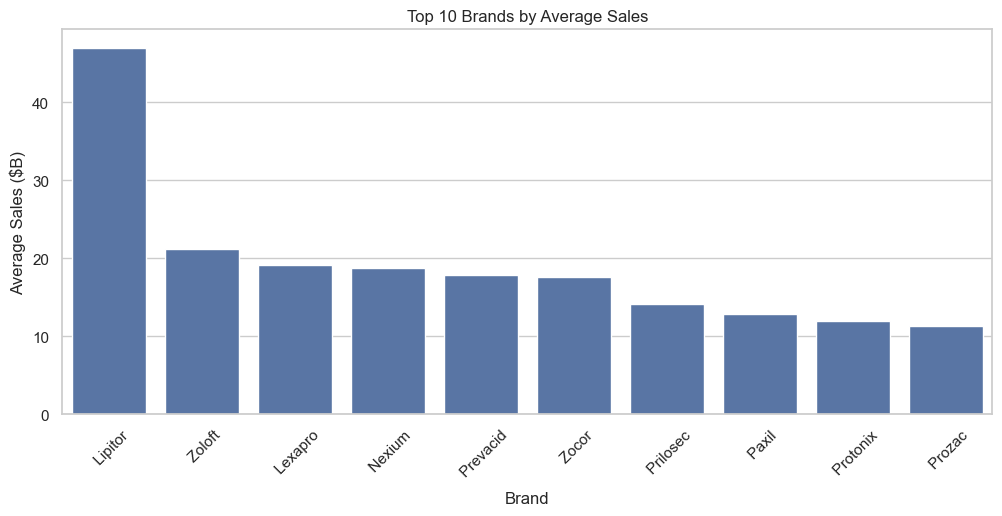


[Business Insight]
The top 5 brands account for approximately 52.2% of portfolio average sales.
This indicates meaningful concentration risk and implies that a few brands can disproportionately influence pooled model estimates.


In [48]:
print("\n[EDA] Ranking brands by average sales contribution...")

brand_sales = (
    df.groupby("agent", as_index=False)["actual_sales"]
    .mean()
    .sort_values("actual_sales", ascending=False)
)

brand_sales["sales_share_pct"] = 100 * brand_sales["actual_sales"] / brand_sales["actual_sales"].sum()
brand_sales["cumulative_share_pct"] = brand_sales["sales_share_pct"].cumsum()

display(brand_sales.head(10))

plt.figure(figsize=(12, 5))
sns.barplot(data=brand_sales.head(10), x="agent", y="actual_sales")
plt.title("Top 10 Brands by Average Sales")
plt.xlabel("Brand")
plt.ylabel("Average Sales ($B)")
plt.xticks(rotation=45)
plt.show()

top_5_share = brand_sales.head(5)["sales_share_pct"].sum()

print("\n[Business Insight]")
print(f"The top 5 brands account for approximately {top_5_share:.1f}% of portfolio average sales.")
print("This indicates meaningful concentration risk and implies that a few brands can disproportionately influence pooled model estimates.")

## 2. Growth Trajectory
Before asking which marketing works, we need to understand whether the portfolio is expanding, maturing, or declining.


[EDA] Analyzing portfolio growth trajectory over time...


,year,actual_sales,detailing,direct_to_consumer_ad,sales_yoy_pct,detailing_yoy_pct,dtca_yoy_pct
0,2013,9.9486,45.7758,6.3109,NaN,NaN,NaN
1,2014,11.5475,55.2130,16.1484,16.0714,20.6161,155.8812
2,2015,13.1646,50.1752,16.3910,14.0041,-9.1242,1.5025
3,2016,14.4348,54.1879,15.6212,9.6486,7.9974,-4.6969
4,2017,14.4936,58.6714,31.1021,0.4072,8.2740,99.1020
5,2018,13.9928,57.9632,29.7359,-3.4555,-1.2071,-4.3926
6,2019,12.6725,54.2737,32.8522,-9.4353,-6.3652,10.4801
7,2020,12.1514,65.0097,34.3327,-4.1124,19.7812,4.5066
8,2021,11.4936,67.2739,42.0747,-5.4132,3.4829,22.5497
9,2022,10.6978,59.1707,28.6292,-6.9237,-12.0451,-31.9561


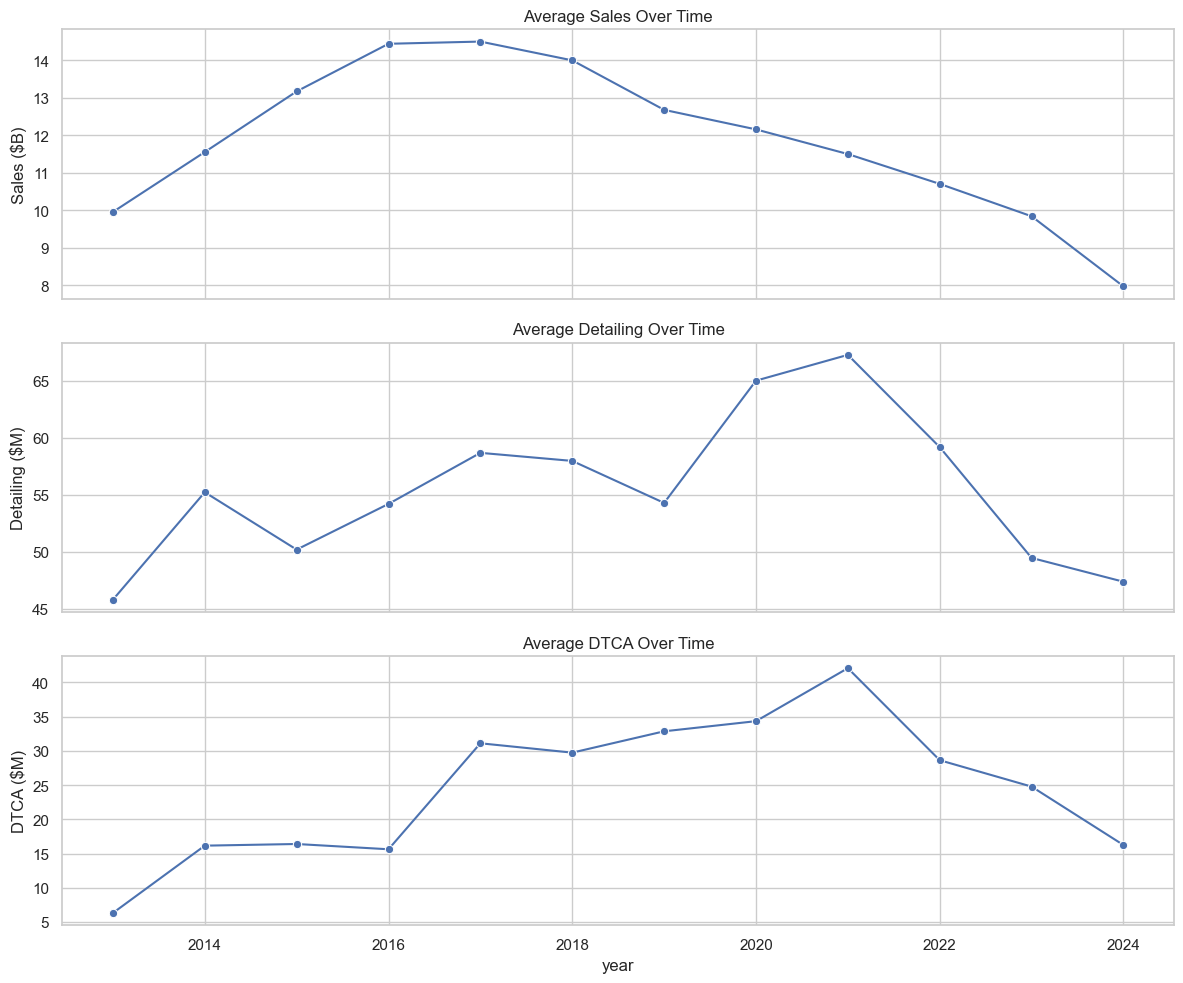


[Business Insight]
The portfolio shows a non-linear lifecycle, with sales rising through the middle years and declining toward 2024.
This implies that a simple linear time trend is unlikely to capture the commercial dynamics adequately.


In [49]:
print("\n[EDA] Analyzing portfolio growth trajectory over time...")

yearly = (
    df.groupby("year", as_index=False)[["actual_sales", "detailing", "direct_to_consumer_ad"]]
    .mean()
)

yearly["sales_yoy_pct"] = yearly["actual_sales"].pct_change() * 100
yearly["detailing_yoy_pct"] = yearly["detailing"].pct_change() * 100
yearly["dtca_yoy_pct"] = yearly["direct_to_consumer_ad"].pct_change() * 100

display(yearly)

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

sns.lineplot(data=yearly, x="year", y="actual_sales", marker="o", ax=axes[0])
axes[0].set_title("Average Sales Over Time")
axes[0].set_ylabel("Sales ($B)")

sns.lineplot(data=yearly, x="year", y="detailing", marker="o", ax=axes[1])
axes[1].set_title("Average Detailing Over Time")
axes[1].set_ylabel("Detailing ($M)")

sns.lineplot(data=yearly, x="year", y="direct_to_consumer_ad", marker="o", ax=axes[2])
axes[2].set_title("Average DTCA Over Time")
axes[2].set_ylabel("DTCA ($M)")

plt.tight_layout()
plt.show()

print("\n[Business Insight]")
print("The portfolio shows a non-linear lifecycle, with sales rising through the middle years and declining toward 2024.")
print("This implies that a simple linear time trend is unlikely to capture the commercial dynamics adequately.")


[EDA] Comparing class-level sales trends over time...


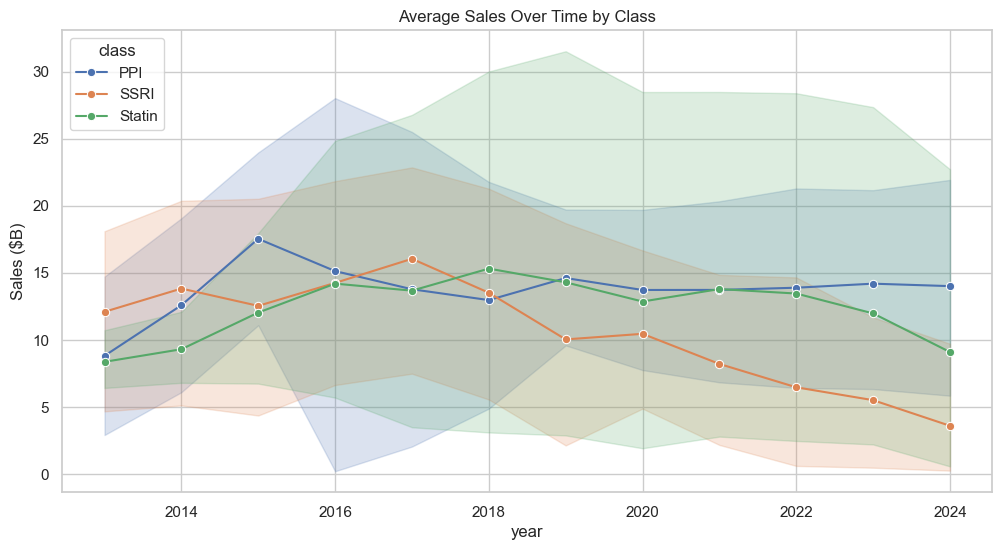


[Business Insight]
Classes do not follow identical trajectories, suggesting that both market maturity and class-specific dynamics shape demand.
This supports the later use of class controls and year effects in the parametric model.


In [50]:
print("\n[EDA] Comparing class-level sales trends over time...")

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="year", y="actual_sales", hue="class", marker="o")
plt.title("Average Sales Over Time by Class")
plt.ylabel("Sales ($B)")
plt.show()

print("\n[Business Insight]")
print("Classes do not follow identical trajectories, suggesting that both market maturity and class-specific dynamics shape demand.")
print("This supports the later use of class controls and year effects in the parametric model.")

## 3. Budget Allocation
The next question is how the firm allocates detailing and DTCA budgets across classes and brands.


[EDA] Summarizing average budget allocation by class...


,class,actual_sales,detailing,direct_to_consumer_ad
0,PPI,13.8355,78.5221,42.9419
2,Statin,12.4964,48.5592,31.7618
1,SSRI,9.5923,49.9067,11.2310


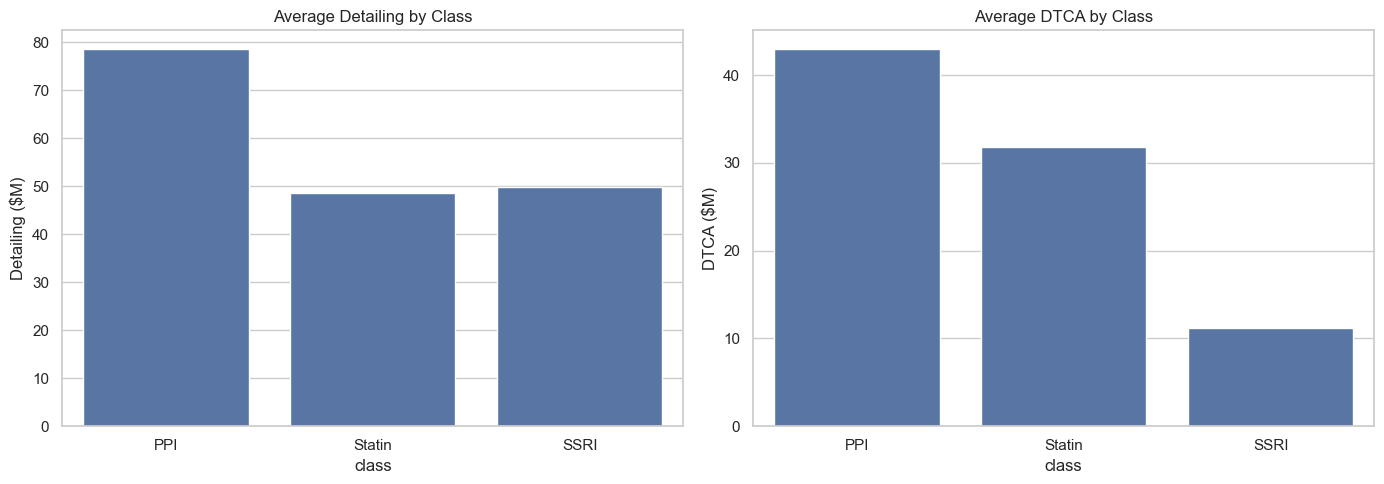


[Business Insight]
The company does not deploy the same marketing mix across classes.
This suggests that channel strategy is likely class-contingent, not one-size-fits-all.


In [51]:
print("\n[EDA] Summarizing average budget allocation by class...")

class_spend = (
    df.groupby("class", as_index=False)[["actual_sales", "detailing", "direct_to_consumer_ad"]]
    .mean()
    .sort_values("actual_sales", ascending=False)
)

display(class_spend)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=class_spend, x="class", y="detailing", ax=axes[0])
axes[0].set_title("Average Detailing by Class")
axes[0].set_ylabel("Detailing ($M)")

sns.barplot(data=class_spend, x="class", y="direct_to_consumer_ad", ax=axes[1])
axes[1].set_title("Average DTCA by Class")
axes[1].set_ylabel("DTCA ($M)")

plt.tight_layout()
plt.show()

print("\n[Business Insight]")
print("The company does not deploy the same marketing mix across classes.")
print("This suggests that channel strategy is likely class-contingent, not one-size-fits-all.")

In [52]:
print("\n[EDA] Identifying brands with the highest marketing investment...")

brand_spend = (
    df.groupby("agent", as_index=False)[["actual_sales", "detailing", "direct_to_consumer_ad"]]
    .mean()
    .sort_values("detailing", ascending=False)
)

display(brand_spend.head(10))

print("\n[Business Insight]")
print("Some brands are detailing-heavy, some are DTCA-heavy, and some invest materially in both channels.")
print("This variation provides the commercial heterogeneity that the later model must explain.")


[EDA] Identifying brands with the highest marketing investment...


,agent,actual_sales,detailing,direct_to_consumer_ad
6,Lexapro,19.1402,192.7008,0.7499
10,Nexium,18.7587,153.0828,182.8566
3,Crestor,7.9550,142.5837,119.2919
7,Lipitor,47.0275,124.0093,80.7884
15,Prevacid,17.8747,92.0651,38.7137
17,Protonix,12.0249,83.2735,3.3244
21,Zoloft,21.1441,80.4162,30.3664
20,Zocor,17.6050,70.3491,54.1879
0,Aciphex,5.8032,66.7499,1.1366
12,Paxil CR,4.8374,53.8639,24.0865



[Business Insight]
Some brands are detailing-heavy, some are DTCA-heavy, and some invest materially in both channels.
This variation provides the commercial heterogeneity that the later model must explain.


## 4. Baseline Efficiency
Before formal modeling, it is useful to compute simple descriptive efficiency ratios: how much revenue is associated with each unit of spend?

In [53]:
print("\n[EDA] Computing descriptive baseline efficiency by channel...")

efficiency = df.copy()
efficiency["sales_per_detailing"] = np.where(
    efficiency["detailing"] > 0,
    efficiency["actual_sales"] / efficiency["detailing"],
    np.nan
)
efficiency["sales_per_dtca"] = np.where(
    efficiency["direct_to_consumer_ad"] > 0,
    efficiency["actual_sales"] / efficiency["direct_to_consumer_ad"],
    np.nan
)

efficiency_summary = (
    efficiency.groupby("class")[["sales_per_detailing", "sales_per_dtca"]]
    .mean()
    .sort_values("sales_per_detailing", ascending=False)
)

display(efficiency_summary)

avg_eff = efficiency[["sales_per_detailing", "sales_per_dtca"]].mean()
display(avg_eff.to_frame("portfolio_avg_efficiency"))

print("\n[Business Insight]")
print("These ratios are highly sensitive to low spend levels and structural zeros, particularly in DTCA. As a result, they should be interpreted cautiously and should not be used as a basis for strategic decisions without controlled modeling.")


[EDA] Computing descriptive baseline efficiency by channel...


,sales_per_detailing,sales_per_dtca
class,,
Statin,0.5474,59.6006
PPI,0.3913,335.6168
SSRI,0.3591,"1,979.3762"


,portfolio_avg_efficiency
sales_per_detailing,0.4387
sales_per_dtca,739.4620



[Business Insight]
These ratios are highly sensitive to low spend levels and structural zeros, particularly in DTCA. As a result, they should be interpreted cautiously and should not be used as a basis for strategic decisions without controlled modeling.


## 5. Distribution Shape and Market Structure
We now examine whether sales and spend are broadly distributed or concentrated in a small number of observations.


[EDA] Visualizing raw distributions of sales and marketing spend...


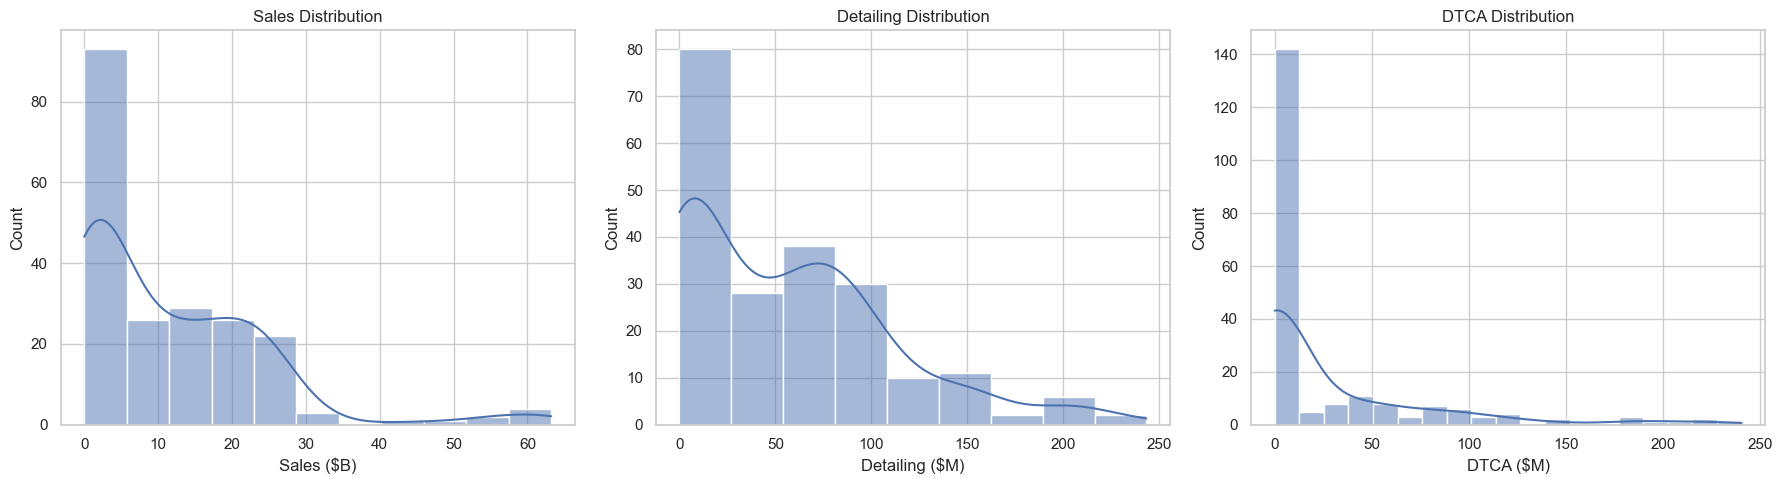


[Business Insight]
All three variables are strongly right-skewed, which is typical in blockbuster-driven markets.
A small number of brands or campaigns account for a disproportionate share of scale.


In [54]:
print("\n[EDA] Visualizing raw distributions of sales and marketing spend...")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df["actual_sales"], kde=True, ax=axes[0])
axes[0].set_title("Sales Distribution")
axes[0].set_xlabel("Sales ($B)")

sns.histplot(df["detailing"], kde=True, ax=axes[1])
axes[1].set_title("Detailing Distribution")
axes[1].set_xlabel("Detailing ($M)")

sns.histplot(df["direct_to_consumer_ad"], kde=True, ax=axes[2])
axes[2].set_title("DTCA Distribution")
axes[2].set_xlabel("DTCA ($M)")

plt.tight_layout()
plt.show()

print("\n[Business Insight]")
print("All three variables are strongly right-skewed, which is typical in blockbuster-driven markets.")
print("A small number of brands or campaigns account for a disproportionate share of scale.")

In [55]:
print("\n[EDA] Quantifying skewness in raw variables...")

skewness_raw = df[["actual_sales", "detailing", "direct_to_consumer_ad"]].skew()
display(skewness_raw.to_frame("skewness"))

print("\n[Business Insight]")
print("Positive skew confirms that raw-scale relationships are likely to be influenced by extreme observations.")
print("This motivates transformed specifications before parametric modeling.")


[EDA] Quantifying skewness in raw variables...


,skewness
actual_sales,1.7127
detailing,1.0358
direct_to_consumer_ad,2.2988



[Business Insight]
Positive skew confirms that raw-scale relationships are likely to be influenced by extreme observations.
This motivates transformed specifications before parametric modeling.


## 6. Spend Saturation and Diminishing Returns
The next business question is whether more spend always produces proportionally more sales.


[EDA] Testing for diminishing returns in detailing using LOWESS...


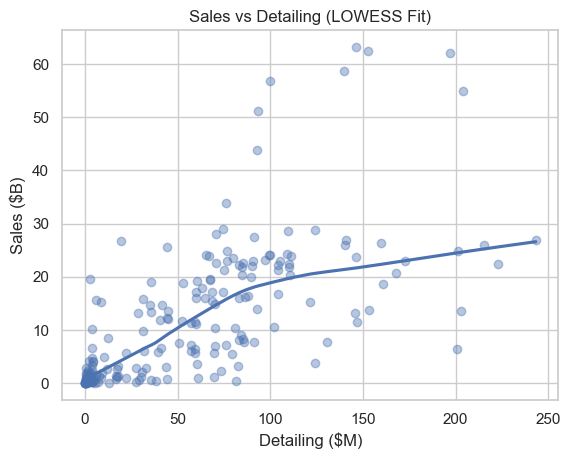


[Business Insight]
The curve flattens at higher spend levels, which is consistent with diminishing marginal returns to detailing.


In [56]:
print("\n[EDA] Testing for diminishing returns in detailing using LOWESS...")

sns.regplot(
    data=df,
    x="detailing",
    y="actual_sales",
    lowess=True,
    scatter_kws={"alpha": 0.4}
)

plt.title("Sales vs Detailing (LOWESS Fit)")
plt.xlabel("Detailing ($M)")
plt.ylabel("Sales ($B)")
plt.show()

print("\n[Business Insight]")
print("The curve flattens at higher spend levels, which is consistent with diminishing marginal returns to detailing.")

In [57]:
print("\n[EDA] Approximating where detailing saturation begins...")

df["detailing_bucket"] = pd.qcut(df["detailing"], q=10, duplicates="drop")
bucket_sales = df.groupby("detailing_bucket", observed=False)["actual_sales"].mean().to_frame("avg_sales")

display(bucket_sales)

print("\n[Business Insight]")
print("Sales increase with higher spend, but at a decreasing rate, reinforcing the presence of diminishing returns..")
print("That pattern suggests spend saturation rather than constant incremental returns.")


[EDA] Approximating where detailing saturation begins...


,avg_sales
detailing_bucket,
"(-0.001, 0.639]",0.3719
"(0.639, 2.96]",2.0414
"(2.96, 6.907]",2.9686
"(6.907, 28.631]",4.5371
"(28.631, 44.969]",8.5018
"(44.969, 67.258]",12.4589
"(67.258, 80.046]",16.5847
"(80.046, 92.864]",16.3139
"(92.864, 134.211]",23.0129



[Business Insight]
Sales increase with higher spend, but at a decreasing rate, reinforcing the presence of diminishing returns..
That pattern suggests spend saturation rather than constant incremental returns.



[EDA] Testing for diminishing returns in DTCA among active advertisers...


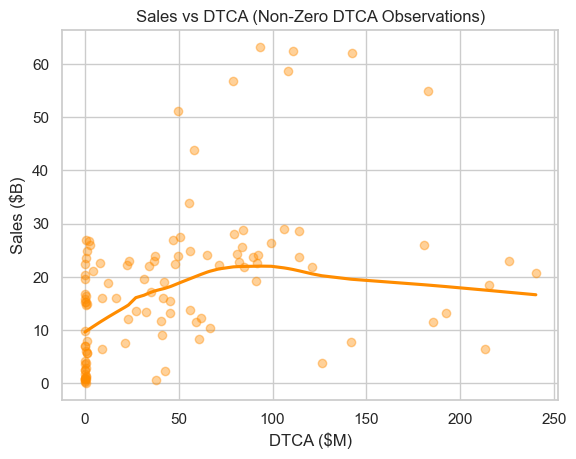


[Business Insight]
Among brands that actually advertise to consumers, the relationship appears positive but not strictly linear.
This supports testing transformed or nonlinear response functions later.


In [58]:
print("\n[EDA] Testing for diminishing returns in DTCA among active advertisers...")

non_zero_dtca = df[df["direct_to_consumer_ad"] > 0]

sns.regplot(
    data=non_zero_dtca,
    x="direct_to_consumer_ad",
    y="actual_sales",
    lowess=True,
    scatter_kws={"alpha": 0.4},
    color="darkorange"
)

plt.title("Sales vs DTCA (Non-Zero DTCA Observations)")
plt.xlabel("DTCA ($M)")
plt.ylabel("Sales ($B)")
plt.show()

print("\n[Business Insight]")
print("Among brands that actually advertise to consumers, the relationship appears positive but not strictly linear.")
print("This supports testing transformed or nonlinear response functions later.")

## 7. Class and Brand Differences in Baseline Sales and Response
A key strategic issue is whether classes and brands differ structurally in both scale and likely marketing response.


[EDA] Comparing baseline sales by class...


,class,actual_sales
0,PPI,13.8355
2,Statin,12.4964
1,SSRI,9.5923


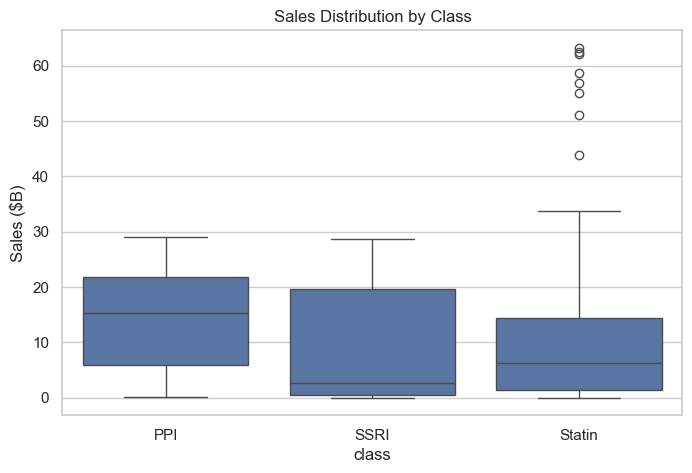


[Business Insight]
Classes differ in both average sales and dispersion.
This indicates that class membership captures meaningful structural differences in demand and competitive conditions.


In [59]:
print("\n[EDA] Comparing baseline sales by class...")

avg_sales_by_class = (
    df.groupby("class", as_index=False)["actual_sales"]
    .mean()
    .sort_values("actual_sales", ascending=False)
)

display(avg_sales_by_class)

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="class", y="actual_sales")
plt.title("Sales Distribution by Class")
plt.ylabel("Sales ($B)")
plt.show()

print("\n[Business Insight]")
print("Classes differ in both average sales and dispersion.")
print("This indicates that class membership captures meaningful structural differences in demand and competitive conditions.")


[EDA] Comparing baseline sales by brand...


,agent,actual_sales
7,Lipitor,47.0275
21,Zoloft,21.1441
6,Lexapro,19.1402
10,Nexium,18.7587
15,Prevacid,17.8747
20,Zocor,17.6050
16,Prilosec,14.1557
11,Paxil,12.8184
17,Protonix,12.0249
18,Prozac,11.2791


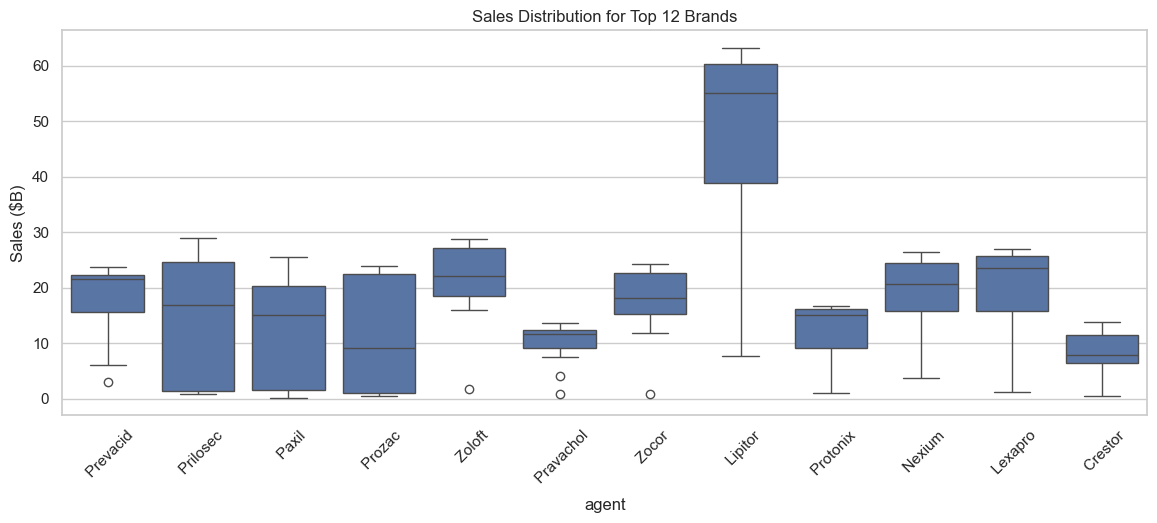


[Business Insight]
Brand-level baseline differences are substantial and extend well beyond class-level effects.
That means agent effects should be treated as a core modeling feature, not a minor control.


In [60]:
print("\n[EDA] Comparing baseline sales by brand...")

avg_sales_by_agent = (
    df.groupby("agent", as_index=False)["actual_sales"]
    .mean()
    .sort_values("actual_sales", ascending=False)
)

display(avg_sales_by_agent.head(15))

top_agents = avg_sales_by_agent.head(12)["agent"].tolist()

plt.figure(figsize=(14, 5))
sns.boxplot(data=df[df["agent"].isin(top_agents)], x="agent", y="actual_sales")
plt.title("Sales Distribution for Top 12 Brands")
plt.ylabel("Sales ($B)")
plt.xticks(rotation=45)
plt.show()

print("\n[Business Insight]")
print("Brand-level baseline differences are substantial and extend well beyond class-level effects.")
print("That means agent effects should be treated as a core modeling feature, not a minor control.")


[EDA] Examining raw response relationships by class...


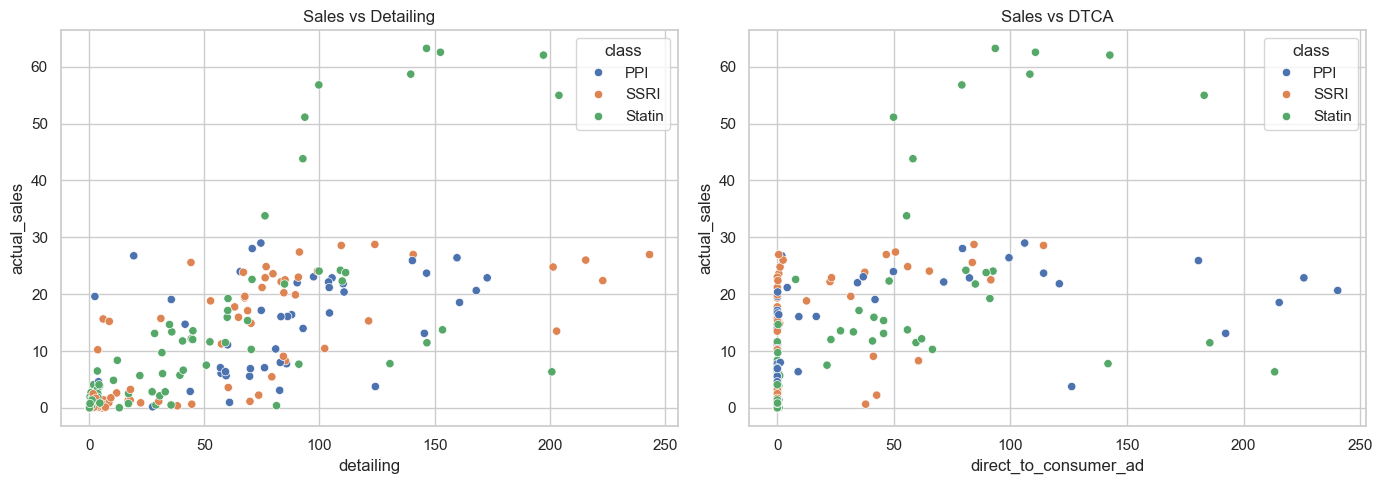


[Business Insight]
The raw relationship between marketing spend and sales is noisy, reinforcing the need for transformed specifications..


In [61]:
print("\n[EDA] Examining raw response relationships by class...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x="detailing", y="actual_sales", hue="class", ax=axes[0])
axes[0].set_title("Sales vs Detailing")

sns.scatterplot(data=df, x="direct_to_consumer_ad", y="actual_sales", hue="class", ax=axes[1])
axes[1].set_title("Sales vs DTCA")

plt.tight_layout()
plt.show()

print("\n[Business Insight]")
print("The raw relationship between marketing spend and sales is noisy, reinforcing the need for transformed specifications..")

## 8. Structural Zero-DTCA Regime
A large share of observations show exactly zero DTCA, which may reflect a distinct strategic regime rather than just low spend.

In [62]:
print("\n[EDA] Measuring the prevalence and structure of zero DTCA...")

df["dtca_zero"] = (df["direct_to_consumer_ad"] == 0).astype(int)

zero_dtca = df["dtca_zero"].sum()
total = len(df)

print(f"Zero DTCA observations: {zero_dtca}")
print(f"Total observations: {total}")
print(f"Share of zero-DTCA observations: {zero_dtca / total:.2%}")

print("\nZero DTCA by class:")
display(pd.crosstab(df["class"], df["dtca_zero"]))

print("\nZero DTCA by year:")
display(pd.crosstab(df["year"], df["dtca_zero"]))

print("\n[Business Insight]")
print("A meaningful share of brands operate without DTCA, implying a dual-regime strategy: physician-led brands versus consumer-advertised brands.")
print("That distinction may matter enough to model explicitly later.")


[EDA] Measuring the prevalence and structure of zero DTCA...
Zero DTCA observations: 98
Total observations: 207
Share of zero-DTCA observations: 47.34%

Zero DTCA by class:


dtca_zero,0,1
class,,
PPI,32,16
SSRI,34,47
Statin,43,35



Zero DTCA by year:


dtca_zero,0,1
year,,
2013,3,7
2014,5,6
2015,6,6
2016,6,7
2017,7,8
2018,12,5
2019,12,8
2020,10,11
2021,13,9



[Business Insight]
A meaningful share of brands operate without DTCA, implying a dual-regime strategy: physician-led brands versus consumer-advertised brands.
That distinction may matter enough to model explicitly later.


## 9. Log Transformations for Parametric Modeling
Because the raw variables are highly skewed and the commercial response appears multiplicative, we prepare log variables for the next stage.

In [63]:
print("\n[EDA] Creating log-transformed variables for next-stage modeling...")

df["log_sales"] = np.log1p(df["actual_sales"])
df["log_detailing"] = np.log1p(df["detailing"])
df["log_dtca"] = np.log1p(df["direct_to_consumer_ad"])

print("[EDA] Log variables created: log_sales, log_detailing, log_dtca")


[EDA] Creating log-transformed variables for next-stage modeling...
[EDA] Log variables created: log_sales, log_detailing, log_dtca



[EDA] Comparing raw and log-transformed distributions...


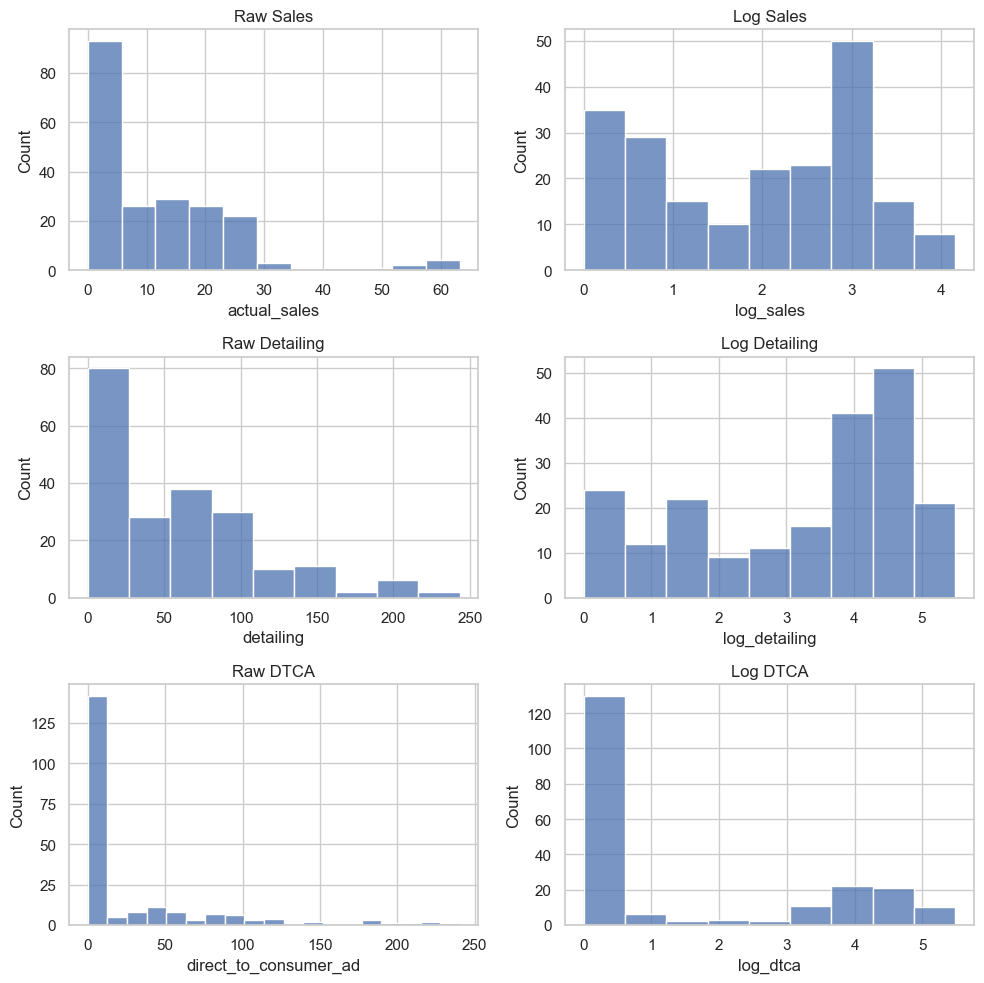


[Business Insight]
The log transform compresses extreme values and produces more stable distributions, especially for sales and detailing.
DTCA improves as well, though the mass at zero remains a structural feature.


In [64]:
print("\n[EDA] Comparing raw and log-transformed distributions...")

fig, axes = plt.subplots(3, 2, figsize=(10, 10))

sns.histplot(df["actual_sales"], ax=axes[0, 0])
axes[0, 0].set_title("Raw Sales")

sns.histplot(df["log_sales"], ax=axes[0, 1])
axes[0, 1].set_title("Log Sales")

sns.histplot(df["detailing"], ax=axes[1, 0])
axes[1, 0].set_title("Raw Detailing")

sns.histplot(df["log_detailing"], ax=axes[1, 1])
axes[1, 1].set_title("Log Detailing")

sns.histplot(df["direct_to_consumer_ad"], ax=axes[2, 0])
axes[2, 0].set_title("Raw DTCA")

sns.histplot(df["log_dtca"], ax=axes[2, 1])
axes[2, 1].set_title("Log DTCA")

plt.tight_layout()
plt.show()

print("\n[Business Insight]")
print("The log transform compresses extreme values and produces more stable distributions, especially for sales and detailing.")
print("DTCA improves as well, though the mass at zero remains a structural feature.")

In [65]:
print("\n[EDA] Comparing skewness before and after log transformation...")

skew_before = df[["actual_sales", "detailing", "direct_to_consumer_ad"]].skew()
skew_after = df[["log_sales", "log_detailing", "log_dtca"]].skew()

skew_compare = pd.DataFrame({
    "Before": skew_before,
    "After": skew_after
})

display(skew_compare)

print("\n[Business Insight]")
print("Skewness falls materially after log transformation, which strengthens the case for log-based parametric models.")


[EDA] Comparing skewness before and after log transformation...


,Before,After
actual_sales,1.7127,NaN
detailing,1.0358,NaN
direct_to_consumer_ad,2.2988,NaN
log_detailing,NaN,-0.6077
log_dtca,NaN,0.8257
log_sales,NaN,-0.1557



[Business Insight]
Skewness falls materially after log transformation, which strengthens the case for log-based parametric models.



[EDA] Evaluating log-log relationships...


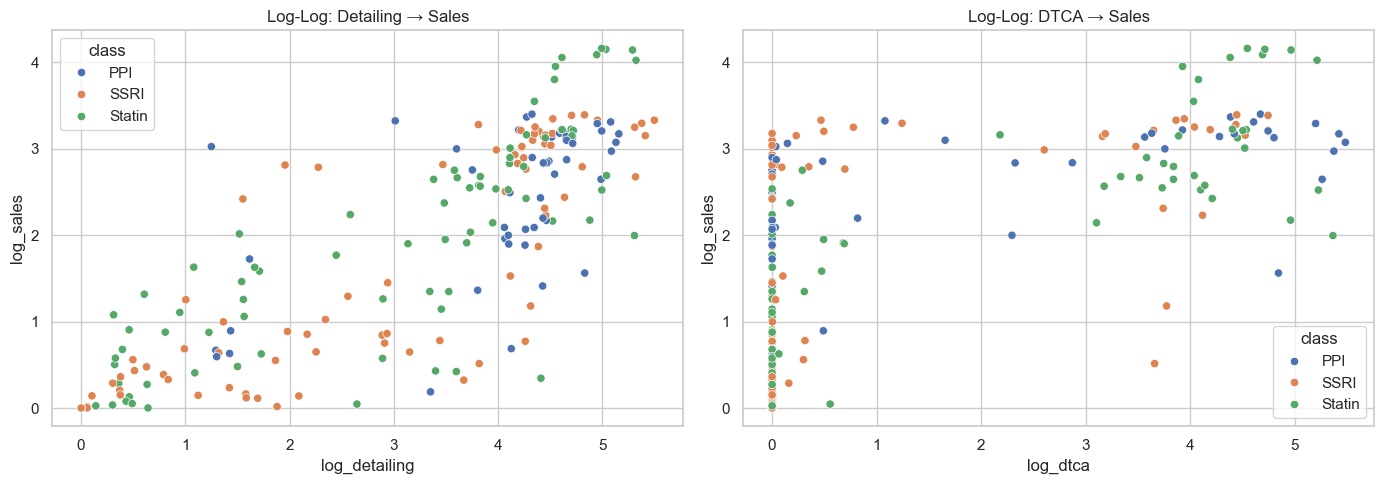


[Business Insight]
Relationships become more linear in log space, supporting elasticity-style interpretation in the next stage.


In [66]:
print("\n[EDA] Evaluating log-log relationships...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x="log_detailing", y="log_sales", hue="class", ax=axes[0])
axes[0].set_title("Log-Log: Detailing → Sales")

sns.scatterplot(data=df, x="log_dtca", y="log_sales", hue="class", ax=axes[1])
axes[1].set_title("Log-Log: DTCA → Sales")

plt.tight_layout()
plt.show()

print("\n[Business Insight]")
print("Relationships become more linear in log space, supporting elasticity-style interpretation in the next stage.")


[EDA] Comparing class-level marketing sensitivity in log space...


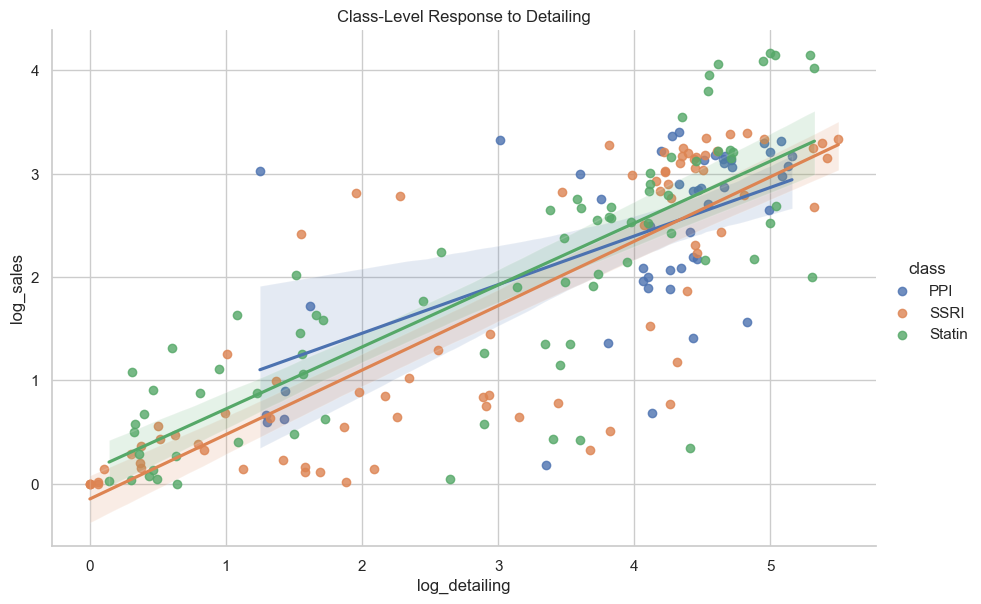


[Business Insight]
Different slopes by class suggest different marketing sensitivities across therapeutic categories.
This supports testing class interaction terms in the parametric model.


In [67]:
print("\n[EDA] Comparing class-level marketing sensitivity in log space...")

sns.lmplot(
    data=df,
    x="log_detailing",
    y="log_sales",
    hue="class",
    height=6,
    aspect=1.5
)

plt.title("Class-Level Response to Detailing")
plt.show()

print("\n[Business Insight]")
print("Different slopes by class suggest different marketing sensitivities across therapeutic categories.")
print("This supports testing class interaction terms in the parametric model.")

## 10. Cross-Channel Strategy and Collinearity
Do brands tend to invest in both channels together, or do they specialize?


[EDA] Examining the relationship between detailing and DTCA...


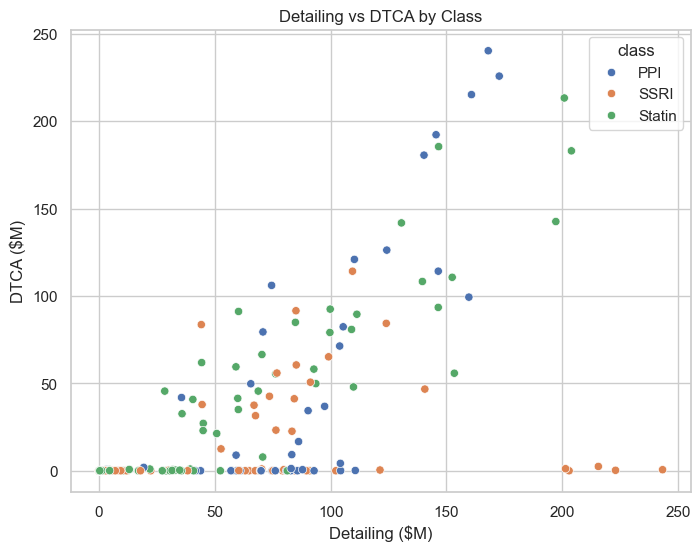


[Business Insight]
Some classes appear to invest jointly across both channels, while others skew more heavily toward one.
This informs both channel strategy interpretation and later multicollinearity checks.


In [68]:
print("\n[EDA] Examining the relationship between detailing and DTCA...")

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="detailing",
    y="direct_to_consumer_ad",
    hue="class"
)
plt.title("Detailing vs DTCA by Class")
plt.xlabel("Detailing ($M)")
plt.ylabel("DTCA ($M)")
plt.show()

print("\n[Business Insight]")
print("Some classes appear to invest jointly across both channels, while others skew more heavily toward one.")
print("This informs both channel strategy interpretation and later multicollinearity checks.")


[EDA] Calculating correlation matrix for log-transformed variables...


,log_sales,log_detailing,log_dtca
log_sales,1.0000,0.8027,0.6482
log_detailing,0.8027,1.0000,0.5953
log_dtca,0.6482,0.5953,1.0000


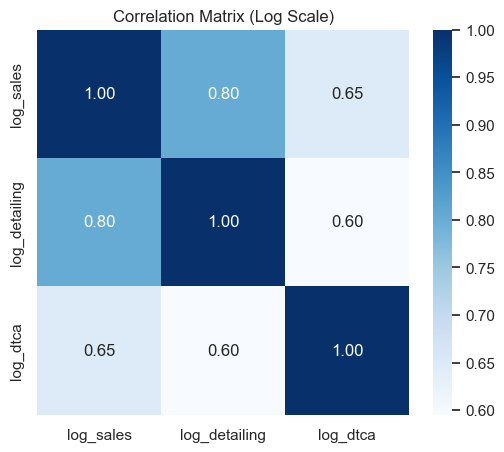


[Business Insight]
Detailing and DTCA show moderate correlation, suggesting some coordinated investment strategies. While not severe, this relationship should be monitored in regression diagnostics.


In [69]:
print("\n[EDA] Calculating correlation matrix for log-transformed variables...")

corr = df[["log_sales", "log_detailing", "log_dtca"]].corr()

display(corr)

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Matrix (Log Scale)")
plt.show()

print("\n[Business Insight]")
print("Detailing and DTCA show moderate correlation, suggesting some coordinated investment strategies. While not severe, this relationship should be monitored in regression diagnostics.")

## 11. Panel Structure and Within-Brand Dynamics
To isolate marketing response credibly, we need to look beyond cross-sectional size and examine within-brand changes over time.


[EDA] Exploring within-brand trajectories for selected brands...


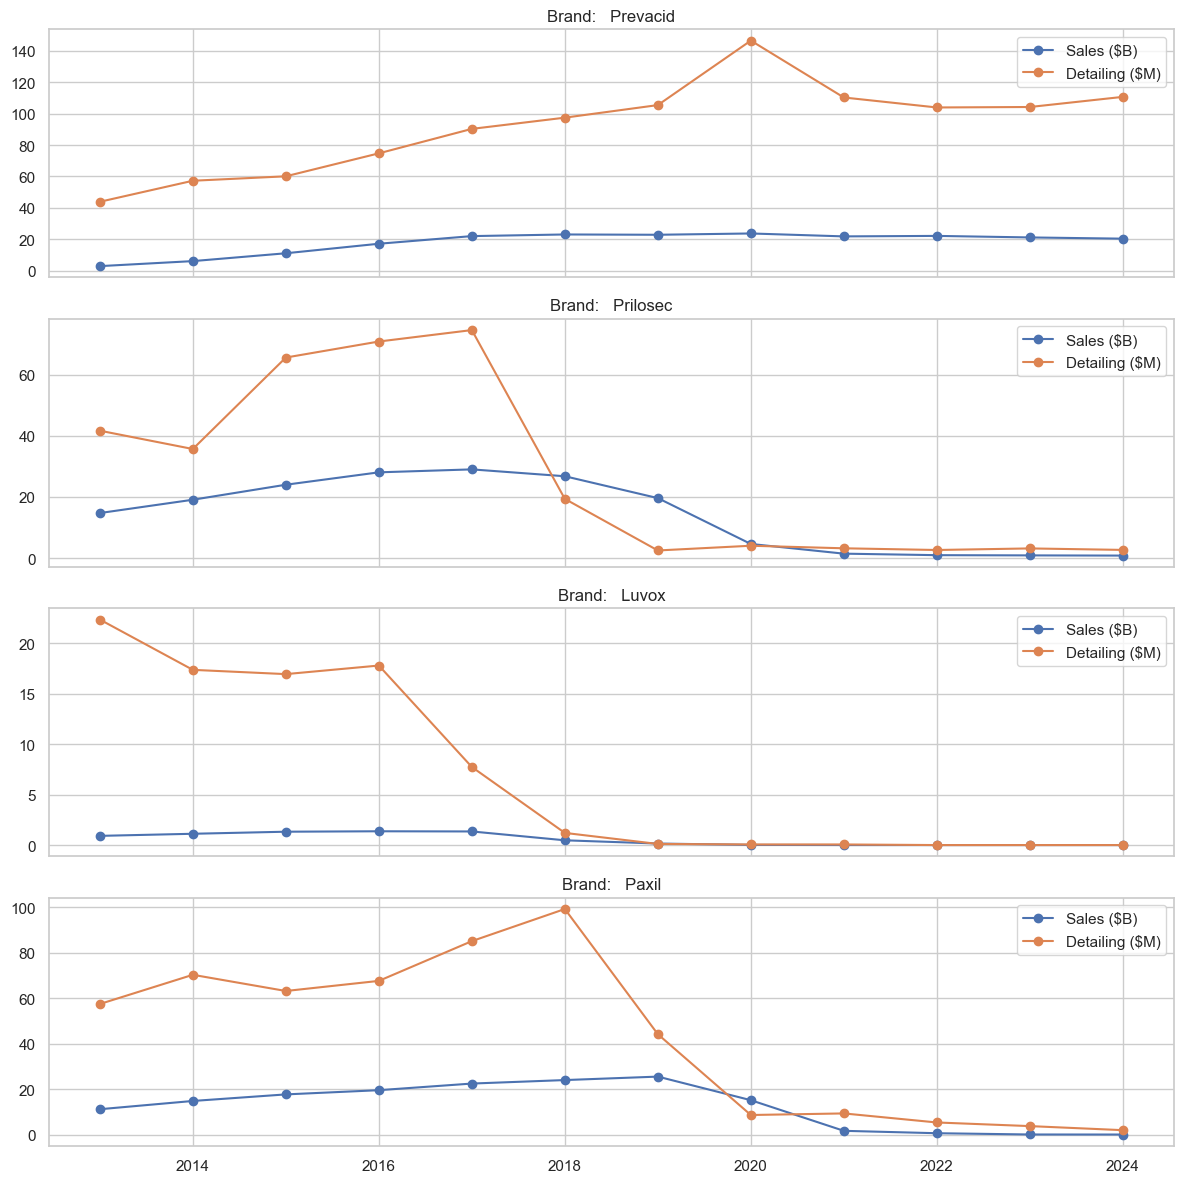


[Business Insight]
Within-brand variation confirms that changes in marketing over time are associated with changes in sales, which forms the basis for identifying marketing effects in panel models.
That is the variation panel-style parametric models exploit for identification.


In [70]:
print("\n[EDA] Exploring within-brand trajectories for selected brands...")

sample_agents = df["agent"].drop_duplicates().head(4).tolist()

fig, axes = plt.subplots(len(sample_agents), 1, figsize=(12, 12), sharex=True)

for i, a in enumerate(sample_agents):
    temp = df[df["agent"] == a].sort_values("year")
    axes[i].plot(temp["year"], temp["actual_sales"], marker="o", label="Sales ($B)")
    axes[i].plot(temp["year"], temp["detailing"], marker="o", label="Detailing ($M)")
    axes[i].set_title(f"Brand: {a}")
    axes[i].legend()

plt.tight_layout()
plt.show()

print("\n[Business Insight]")
print("Within-brand variation confirms that changes in marketing over time are associated with changes in sales, which forms the basis for identifying marketing effects in panel models.")
print("That is the variation panel-style parametric models exploit for identification.")


[EDA] Inferring brand lifecycle patterns...


,start_year,end_year,avg_sales
agent,,,
Zoloft,2013,2024,21.1441
Prozac,2013,2024,11.2791
Prilosec,2013,2024,14.1557
Lescol,2013,2024,3.6356
Prevacid,2013,2024,17.8747
Pravachol,2013,2024,9.9861
Luvox,2013,2024,0.5595
Mevacor,2013,2024,2.1499
Zocor,2013,2024,17.6050


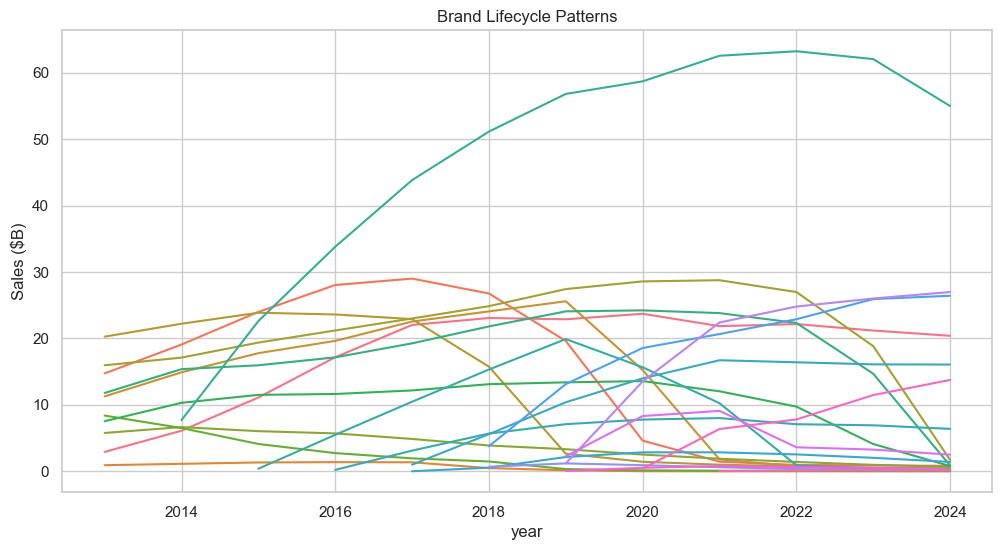


[Business Insight]
Brands exhibit distinct lifecycle patterns, including entry, growth, and decline, which influence both sales levels and observed marketing effectiveness.
Lifecycle effects may also shape the apparent return to marketing spend.


In [71]:
print("\n[EDA] Inferring brand lifecycle patterns...")

agent_lifecycle = (
    df.groupby("agent")
    .agg(
        start_year=("year", "min"),
        end_year=("year", "max"),
        avg_sales=("actual_sales", "mean")
    )
    .sort_values("start_year")
)

display(agent_lifecycle.head(15))

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="year", y="actual_sales", hue="agent", legend=False)
plt.title("Brand Lifecycle Patterns")
plt.ylabel("Sales ($B)")
plt.show()

print("\n[Business Insight]")
print("Brands exhibit distinct lifecycle patterns, including entry, growth, and decline, which influence both sales levels and observed marketing effectiveness.")
print("Lifecycle effects may also shape the apparent return to marketing spend.")

## 12. Outliers and High-Leverage Observations
Before modeling, we identify whether a few brands or campaigns are likely to dominate results.

In [72]:
print("\n[EDA] Reviewing highest-leverage observations...")

print("Top 5 by sales:")
display(df.nlargest(5, "actual_sales")[["class", "agent", "year", "actual_sales", "detailing", "direct_to_consumer_ad"]])

print("Top 5 by detailing:")
display(df.nlargest(5, "detailing")[["class", "agent", "year", "actual_sales", "detailing", "direct_to_consumer_ad"]])

print("Top 5 by DTCA:")
display(df.nlargest(5, "direct_to_consumer_ad")[["class", "agent", "year", "actual_sales", "detailing", "direct_to_consumer_ad"]])

print("\n[Business Insight]")
print("These observations are not errors; they represent structurally important brands or campaigns.")
print("However, they may exert high leverage on pooled model estimates, so robustness checks will be prudent later.")


[EDA] Reviewing highest-leverage observations...
Top 5 by sales:


,class,agent,year,actual_sales,detailing,direct_to_consumer_ad
159,Statin,Lipitor,2022,63.2186,146.4874,93.4800
137,Statin,Lipitor,2021,62.5406,152.5107,110.7082
181,Statin,Lipitor,2023,62.0389,197.2503,142.6181
115,Statin,Lipitor,2020,58.6918,139.6403,108.3209
94,Statin,Lipitor,2019,56.7952,99.7099,79.1343


Top 5 by detailing:


,class,agent,year,actual_sales,detailing,direct_to_consumer_ad
191,SSRI,Lexapro,2024,26.9766,243.3303,0.5963
125,SSRI,Lexapro,2021,22.3924,223.0231,0.2595
169,SSRI,Lexapro,2023,26.0019,215.6069,2.4667
203,Statin,Lipitor,2024,54.9727,203.9765,183.0804
104,SSRI,Lexapro,2020,13.5176,202.9746,0.0000


Top 5 by DTCA:


,class,agent,year,actual_sales,detailing,direct_to_consumer_ad
120,PPI,Nexium,2021,20.6499,168.0683,240.3550
142,PPI,Nexium,2022,22.8833,172.8186,225.8439
99,PPI,Nexium,2020,18.5523,160.8279,215.2616
134,Statin,Crestor,2021,6.3594,200.9031,213.3158
79,PPI,Nexium,2019,13.1240,145.5416,192.2922



[Business Insight]
These observations are not errors; they represent structurally important brands or campaigns.
However, they may exert high leverage on pooled model estimates, so robustness checks will be prudent later.


## 13. EDA Takeaways

In [73]:
print("\n[EDA] Summarizing final business takeaways...")

print("""
1. The portfolio is highly concentrated, with a small number of blockbuster brands driving over half of total revenue.
2. Sales exhibit a clear lifecycle pattern, rising through mid-period before declining, indicating that time dynamics must be explicitly modeled.
3. Marketing investments are not uniformly allocated — both channel mix and spend levels vary significantly across classes and brands.
4. Simple efficiency ratios suggest differences across channels, but are unstable due to structural zeros and should not be interpreted causally.
5. There is consistent evidence of diminishing returns, particularly in detailing, supporting nonlinear or log-transformed specifications.
6. Both class and brand identity materially influence baseline sales and likely response to marketing, justifying their inclusion as structural controls.
7. Nearly half of observations have zero DTCA, indicating a distinct physician-driven marketing regime that must be modeled separately.
8. The dataset is an unbalanced panel, requiring careful time-based validation to avoid bias from brand entry and exit.
9. Log transformations substantially improve distributional properties and linearity, enabling elasticity-based interpretation of model coefficients.
10. Overall, the evidence supports a log-log parametric model with class, brand, and time controls, and a potential regime distinction for DTCA activity.
""")


[EDA] Summarizing final business takeaways...

1. The portfolio is highly concentrated, with a small number of blockbuster brands driving over half of total revenue.
2. Sales exhibit a clear lifecycle pattern, rising through mid-period before declining, indicating that time dynamics must be explicitly modeled.
3. Marketing investments are not uniformly allocated — both channel mix and spend levels vary significantly across classes and brands.
4. Simple efficiency ratios suggest differences across channels, but are unstable due to structural zeros and should not be interpreted causally.
5. There is consistent evidence of diminishing returns, particularly in detailing, supporting nonlinear or log-transformed specifications.
6. Both class and brand identity materially influence baseline sales and likely response to marketing, justifying their inclusion as structural controls.
7. Nearly half of observations have zero DTCA, indicating a distinct physician-driven marketing regime that must 

## Next Steps for Parametric Modeling

This EDA has already prepared the key features needed for the next stage:

- `log_sales`
- `log_detailing`
- `log_dtca`
- `dtca_zero`

### Recommended first parametric baseline

\[
\log(1 + Sales) \sim \log(1 + Detailing) + \log(1 + DTCA) + Class + Agent + Year
\]

### Extensions suggested by the EDA
- class × channel interaction terms
- `dtca_zero` as a binary regime indicator
- nonlinear response checks if residual diagnostics suggest misfit
- robustness checks for high-leverage brands

In [74]:
print("\n[EDA] Saving processed dataset for the next modeling stage...")

df.to_csv("data/processed_data.csv", index=False)

print("[EDA] Saved processed file: data/processed_data.csv")


[EDA] Saving processed dataset for the next modeling stage...
[EDA] Saved processed file: data/processed_data.csv
